In [6]:
"""
water_mass_transport.py
author: Tahya Weiss-Gibbons (adapted by Grace Kirkpatrick)

Calculate the transport across a straight line section of a water mass
Gives volume, heat, freshwater and salt transport of the water mass
"""
import math
import datetime
import numpy as np
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset
import datetime
import matplotlib.pyplot as plt
import cftime
import time
import gsw

In [13]:
#gets the list of grid points for a straight section between two points
#uses the bresenham line algorithm
def plotLineLow(x0, x1, y0, y1):
    ii = []
    jj = []

    dx = x1 -x0
    dy = y1 - y0
    
    yi = 1
    if dy < 0:
        yi = -1
        dy = -dy
    D = (2*dy) - dx
    y = y0
    for x in range(x0, x1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            y = y+yi
            D = D+(2*(dy-dx))
            ii.append(x)
            jj.append(y)
        else:
            D = D+2*dy
    return ii, jj

def plotLineHigh(x0, x1, y0, y1):
    ii = []
    jj = []

    dx = x1 - x0
    dy = y1 - y0
    
    xi = 1
    if dx < 0:
        xi = -1
        dx = -dx
    D = (2*dx) - dy
    x = x0

    for y in range(y0, y1):
        ii.append(x)
        jj.append(y)
        if D > 0:
            x = x+xi
            D = D + (2*(dx-dy))
            ii.append(x)
            jj.append(y)
        else:
            D = D + 2*dx
    return ii, jj

def section_calculation(x0, x1, y0, y1):
    
    if abs(y1-y0) < abs(x1-x0):
        if x0 > x1:
            ii, jj = plotLineLow(x1, x0, y1, y0)
        else:
            ii, jj = plotLineLow(x0, x1, y0, y1)
    else:
            if y0 > y1:
                ii, jj = plotLineHigh(x1, x0, y1, y0)
            else:
                ii, jj = plotLineHigh(x0, x1, y0, y1)
    return ii, jj
    
#then shifts ii jj indices (whole dataset indices) to subset indices 
def shift_subset_bounds(ii, jj):
    ii = [x - ii[0] for x in ii]
    jj = [x - jj[0] for x in jj]
    return ii, jj

In [14]:
def time_bounds(startyear, startmonth, startday, endyear, endmonth, endday):
    return [startyear, startmonth, startday, endyear, endmonth, endday]

def space_bounds(n1, n2, n3, n4):
    return [n1, n2, n3, n4]

def get_times(dates):
    start_time = datetime.date(dates[0], dates[1], dates[2])
    end_time = datetime.date(dates[3], dates[4], dates[5])

    #figure out all the dates we have model files
    delta = end_time - start_time
    times = []

    i = 0
    while i < delta.days+1:
        t = start_time + datetime.timedelta(days=i)
        if t.month == 2 and t.day == 29:
            t = datetime.date(t.year, 3, 1)
            i = i+6
        else:
            i = i+5
        times.append(t)

    return times

In [15]:
def preprocess_v(ds): 
    ds = ds[['vomecrty']]
    ds = ds.sel(x=slice(inds[0],inds[1] + 1))
    ds = ds.sel(y=slice(inds[2],inds[3] + 1))
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_u(ds): 
    ds = ds[['vozocrtx']]
    ds = ds.sel(x=slice(inds[0],inds[1]+ 1))
    ds = ds.sel(y=slice(inds[2],inds[3]+ 1))
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_t(ds): 
    ds = ds[['vosaline', 'votemper']]
    if inds[0]==inds[1]: ds = ds.sel(x_grid_T = inds[0])
    else: ds = ds.sel(x_grid_T=slice(inds[0], inds[1]))
    if inds[2]==inds[3]: ds = ds.sel(y_grid_T = inds[3])
    else: ds = ds.sel(y_grid_T=slice(inds[2], inds[3]))                         
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all

def preprocess_mask(ds): # mask is on t-grid! but variables are not named the same
    ds = ds[['e1t', 'e2t', 'e3t', 'nav_lon', 'nav_lat', 'nav_lev', 'tmask']]
    if inds[0]==inds[1]: ds = ds.sel(x = inds[0])
    else: ds = ds.sel(x=slice(inds[0], inds[1]))
    if inds[2]==inds[3]: ds = ds.sel(y = inds[3])
    else: ds = ds.sel(y=slice(inds[2], inds[3]))                         
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d all
    
def get_files(path, dpath, runid, times, inds):
    #need both the u and v components of velocity
    inds = inds
    mdl_files_v = []
    mdl_files_u = []
    mdl_files_t = []
    for t in times:
        mdl_files_v.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridV.nc")
        mdl_files_u.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridU.nc")
        mdl_files_t.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridT.nc")

    dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_v)
    du = xr.open_mfdataset(mdl_files_u, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_u)
    dt = xr.open_mfdataset(mdl_files_t, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t)
    mask = xr.open_mfdataset(dpath+'ANHA4_mesh_mask.nc', preprocess=preprocess_mask)

    return dv, du, dt, mask
    

In [199]:
def create_output_file(path, runid, secname, var_3d, var_4d, t_grid_file): 

    #[e1t, e2t, cell_thickness_t, u_trans, v_trans, rho, ctemp, asal, mask_transect]
    var3_names = ['u_thick', 'v_thick', 'z_thick']
    var4_names = ['u_trans', 'v_trans', 'rho', 'ctemp', 'asal']
    
    ncfile = Dataset(path + secname + runid + '.nc', mode='w',format='NETCDF4') 
    ncfile.createDimension('time_counter', None)
    ncfile.createDimension('depth', t_grid_file.deptht.shape[0]) # add some kind of exception for when the shape for each is 1d
    ncfile.createDimension('nav_lat', t_grid_file.nav_lat_grid_T.shape[0])
    ncfile.createDimension('nav_lon', t_grid_file.nav_lon_grid_T.shape[1])
    
    nav_lon = ncfile.createVariable('nav_lon', float, ('nav_lat', 'nav_lon'))
    nav_lat = ncfile.createVariable('nav_lat', float, ('nav_lat', 'nav_lon'))
    time_counter = ncfile.createVariable('time_counter', int, ('time_counter',))
    depth = ncfile.createVariable('depth', float, ('depth',))
    mask = ncfile.createVariable('mask_transect', float, ('depth','nav_lat', 'nav_lon'))
    
    time_counter[:] = cftime.date2num(t_grid_file['time_counter'][:], 'seconds since 1900-01-01 00:00:00', calendar = 'noleap')
    cftime.num2date(time_counter[:], 'seconds since 1900-01-01 00:00:00', calendar = 'noleap')
    depth[:] = t_grid_file['deptht'][:]
    nav_lon[:,:] = t_grid_file['nav_lon_grid_T'][:,:]
    nav_lat[:,:] = t_grid_file['nav_lat_grid_T'][:,:]
    mask[:] = var_4d[-1][:]

    for x in range(len(var3_names)):
        y = ncfile.createVariable(var3_names[x], float, ('depth', 'nav_lat', 'nav_lon'))
        y[:] = var_3d[x][:]

    print(nav_lon.shape)
    print(nav_lat.shape)
    print(depth.shape)
    print(time_counter.shape)

    print(var_4d[0].shape)

    for z in range(len(var4_names)):
        a = ncfile.createVariable(var4_names[z], float, ('time_counter', 'depth', 'nav_lat', 'nav_lon'))
        print(var4_names[z])
        a[:] = var_4d[z][:]

    ncfile.close()

def create_output_wmass(path, secname, runid, wmasses, time_series): 
    
    ncfile = Dataset(path + secname + runid + str(len(wmasses)) + '.nc', mode='w',format='NETCDF4') 
    ncfile.createDimension('time_counter', None)
    ncfile.createDimension('depth,' )
    ncfile.createDimension('alongpath,')
    ncfile.createVariable('time_counter', int, ('time_counter',))
    ncfile.variables['time_counter'] = time_series['time_counter'][:]

    for x in wmasses:
        ncfile.createVariable(x['name'] + 'vol' , float, ('time_counter',))
        ncfile.createVariable(x['name'] + 'sal' , float, ('time_counter',))
        ncfile.createVariable(x['name'] + 'heat' , float, ('time_counter',))
        ncfile.createVariable(x['name'] + 'fresh' , float, ('time_counter',))
    return ncfile
    
def get_rho_ct_asal(dt):
    pt = dt['votemper']
    ps = dt['vosaline']
    asal = gsw.SA_from_SP(ps, 10.1325, dt.nav_lon_grid_T, dt.nav_lat_grid_T)
    ct = gsw.CT_from_pt(asal, pt)
    rho = gsw.sigma0(asal, ct)
    
    return rho, ct, asal

def define_watermasses(names, density_bounds): # list of names, list of density characteristics, creates dictionary
    watermasses = []
    for x in range(len(names)):
        watermasses.append({'name':names[x], 'rho':density_bounds[x]})
    return watermasses 

is it faster to subset these datasets or does the additional overhead actually make it slower? or rather how much slower, bc i think using the gibbs formulas at every timestep rather than accessing density directly would be very slow indeed. 33 secs without subsetting; 99 for all three vars; *3 for all years for 5 minutes; 22 secs with subsetting; 66 for all three; 3.3 mins

In [212]:
def transport_calculations(runid, secname, inds, dates):
    figs_path = '/mnt/storage6/grace/nwcorner/scripts/Figures/'
    path = "/mnt/storage6/myers/NEMO/ANHA4-" + runid + "/"
    other_path = '/mnt/storage6/grace/data/'
    
    #get list of times in the dataset from the start date (YYYYMMDD) and end date (YYYYMMDD)
    times = get_times(dates)
    
    #load in dataset (u, v, t grids)
    dv, du, dt, mask = get_files(path, other_path, runid, times, inds)

    print(dv['vomecrty'].shape)

    print('done loading')

    #read in the mask file
    e1t = mask['e1t'][0,:,:]
    e2t = mask['e2t'][0,:,:]
    e3t = mask['e3t'][0,:,:,:]
    tmask = mask['tmask'][0,:,:,:]

    print(e1t.shape)
    print(e2t.shape)

    #and finally the cell thickness
    cell_thickness_t = np.where(tmask, e3t, np.nan)
    
    #now we need to get u and v on the t-grid by averaging u_i and u_(i+1), same for v
    u_t = (du['vozocrtx'][:,:, :, :-1] /2 + du['vozocrtx'][:,:, :, 1:] /2)[:,:,:-1,:]
    v_t = (dv['vomecrty'][:,:, :-1, :] /2 + dv['vomecrty'][:,:, 1:, :] /2)[:,:,:,:-1]

    print(v_t.shape)

    print('done t gridding')
    
    #now that everything is on the t-grid we can use all of the t-grid coordinates and values. 
    #we calculate the area of the cell's vertical face along both the i and j axes

    i_tarea = e1t * e3t # area of vertical cell face along i-axis, for v 
    j_tarea = e2t * e3t # area of vertical cell face alone j-axis horizontal, for u

    print(i_tarea.shape)

    v_trans = i_tarea * v_t *.000001 # meridional transport
    u_trans = j_tarea * u_t *.000001 # zonal transport

    print(v_trans.shape)

    """

    #now we need conservative temp, absolute salinity, and potential density)
    rho, ctemp, asal = get_rho_ct_asal(dt)

    #Define the transect and get the iijj list. The Bresenham Line Calculator doesnt't know about python's ending-exclusing indexing, so we 
    #need to subtract one from our grid i-j index values to avoid getting an out-of-bounds error. 
    iit, jjt = section_calculation(inds[0], inds[1]-1, inds[2], inds[3]-1) # temporary indices in full-output i/j coordinates
    ii, jj = shift_subset_bounds(iit, jjt) # indices shifted to subset i/j coordinates

    mask_transect = np.zeros(e3t.shape)

    for n in range(len(ii)-1): # because our indices were calibrated to the +1/+1 grid we shifted out of, must subtract one
        mask_transect[:, jj[n], ii[n]] += 1
        
    mask_transect = mask_transect.astype(bool)

    out_3list = [e1t, e2t, cell_thickness_t]
    out_4list =  [u_trans, v_trans, rho, ctemp, asal, mask_transect]

    create_output_file(other_path, runid, secname, out_3list, out_4list, dt)

    dt.close()
    du.close()
    dv.close()
    mask.close()
    """

done loading
done t gridding
(10, 30) lat
(10, 30) lon
(50,) dep
(74,) time 
(10, 30, 50, 74, 50) -> should be 74, 50, 10, 30
u_trans

In [213]:
if __name__ == "__main__":
    dates = time_bounds(2004, 1, 5, 2005, 1, 5)
    inds = space_bounds(55+125, 85+125, 85+225, 95+225)
    transport_calculations('EPM151', 'pre_gb_24', inds, dates)

(74, 50, 11, 31)
done loading
(1, 10, 30)
(1, 10, 30)
(74, 50, 10, 30)
done t gridding
(1, 10, 30, 50)
(1, 10, 30, 50, 74, 50)


/mnt/storage6/grace/anaconda/envs/anha4nwcorner/lib/python3.13/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(
/mnt/storage6/grace/anaconda/envs/anha4nwcorner/lib/python3.13/site-packages/dask/array/core.py:5189: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


In [63]:
ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridT.nc")
ds_u4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridU.nc")
ds_v4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridV.nc")

mask = np.zeros((10,10))
py = [0,1,2,3,4,5,6,7,8,9]
px = [0,1,2,3,4,5,6,7,8,9]

In [185]:
def get_files_test(path, runid, times, inds):
    #need both the u and v components of velocity
    inds = inds
    mdl_files_v = []
    #mdl_files_u = []
    #mdl_files_t = []
    for t in times:
        mdl_files_v.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridV.nc")
        #mdl_files_u.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridU.nc")
        #mdl_files_t.append(path+"ANHA4-"+runid+"_y"+str(t.year)+"m"+str(t.month).zfill(2)+"d"+str(t.day).zfill(2)+"_gridT.nc")

    dv = xr.open_mfdataset(mdl_files_v, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_v)
    #du = xr.open_mfdataset(mdl_files_u, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_u)
    #dt = xr.open_mfdataset(mdl_files_t, data_vars='minimal', coords='minimal', compat='override', preprocess=preprocess_t)
    #mask = xr.open_mfdataset(dpath+'ANHA4_mesh_mask.nc', preprocess=preprocess_mask)

    return dv#, du, dt, mask

In [186]:
dates = time_bounds(2004, 1, 5, 2005, 1, 5)
inds = space_bounds(55+125, 85+125, 85+225, 95+225) # something off with ii & jj- figure it out!!!
inddates = get_times(dates)
m = get_files_test("/mnt/storage6/myers/NEMO/ANHA4-EPM151/", 'EPM151', inddates, inds) 

In [187]:
m

<xarray.Dataset> Size: 5MB
Dimensions:        (time_counter: 74, depthv: 50, y: 11, x: 31)
Coordinates:
  * time_counter   (time_counter) object 592B 2004-01-03 12:00:00 ... 2005-01...
  * depthv         (depthv) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
    nav_lat        (y, x) float32 1kB dask.array<chunksize=(11, 31), meta=np.ndarray>
    nav_lon        (y, x) float32 1kB dask.array<chunksize=(11, 31), meta=np.ndarray>
    time_centered  (time_counter) object 592B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    vomecrty       (time_counter, depthv, y, x) float32 5MB dask.array<chunksize=(1, 50, 11, 31), meta=np.ndarray>
Attributes:
    name:         ANHA4-EPM151
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2022-Nov-16 12:42:16 EST

In [76]:
u = ds_u4['vozocrtx'][0, 0, 180:210, 310:320]

In [77]:
iit, jjt = section_calculation(inds[0], inds[1]-1, inds[2], inds[3]-1)
ii, jj = shift_subset_bounds(iit, jjt)

In [78]:
mask = np.zeros((30,10))

In [79]:
for z in range(len(ii)):
    mask[ii[z], jj[z]] = 1

In [80]:
mask = mask.astype(bool)

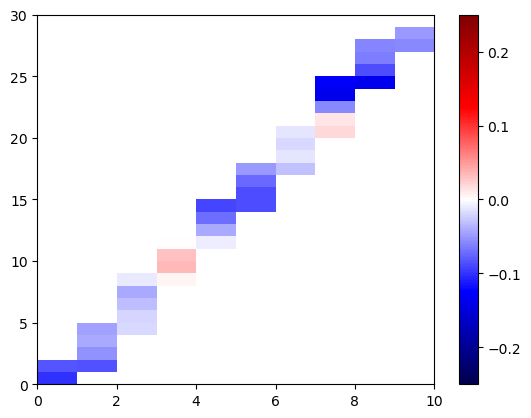

In [84]:
plt.pcolormesh(np.where(mask, u, np.nan),vmin=-.25, vmax=.25, cmap = 'seismic')
plt.colorbar()

In [85]:
v = ds_v4['vomecrty'][0, 0, 180:210, 310:320]

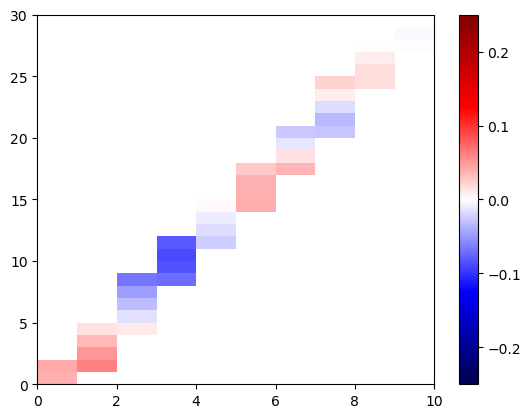

In [87]:
plt.pcolormesh(np.where(mask, v, np.nan),vmin=-.25, vmax=.25, cmap = 'seismic')
plt.colorbar()